# NLPCSS-20 Descriptive Analysis of Model-Predicted Argumentative Units

This notebook analyzes the full-corpus ModernBERT predictions for the NLPCSS-20 corpus.

The analysis uses the filtered prediction file, where predictions consisting of only punctuation marks have been removed. 

The five predicted argumentative-unit labels are:

- assumption
- testimony
- anecdote
- statistics
- other


In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTICLE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "model_predictions"
    / "nlpcss20_article_summary.csv"
)

SPAN_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "results"
    / "model_predictions"
    / "nlpcss20_model_predictions_filtered.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "analysis"
    / "nlpcss20_descriptive_analysis"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = [
    "assumption",
    "testimony",
    "anecdote",
    "statistics",
    "other",
]

EVIDENCE_LABELS = [
    "testimony",
    "anecdote",
    "statistics",
]

## 1. Load the prediction files

This section loads the article summary and the filtered prediction files.

The article summary has one row per article. It is used for distributional analyses by political orientation, topic, and outlet.

The span prediction file has one row per predicted argumentative span. It is used when individual spans or span order are needed.

In [2]:
article_df = pd.read_csv(ARTICLE_SUMMARY_PATH)
span_df = pd.read_csv(SPAN_PREDICTIONS_PATH)

# Keep the final analytical corpus
article_df = article_df[article_df["topics"].notna()].copy()

valid_articles = set(article_df["article_position"])
span_df = span_df[span_df["article_position"].isin(valid_articles)].copy()

print("Article summary")
print("Rows:", len(article_df))
print("Columns:", len(article_df.columns))

print("\nSpan predictions")
print("Rows:", len(span_df))
print("Columns:", len(span_df.columns))

Article summary
Rows: 7616
Columns: 36

Span predictions
Rows: 493785
Columns: 23


## 2. Inspect available variables and missing values

This section checks which variables are available in the article-level summary and how much missing metadata there is. 

In [3]:
print("Article-level columns:")
print(article_df.columns.tolist())

metadata_columns = [
    "source",
    "title",
    "adfontes_fair",
    "adfontes_political",
    "allsides_bias",
    "time",
    "topics",
    "author",
    "word_count",
]

print("\nMissing values in selected metadata columns:")
print(article_df[metadata_columns].isna().sum())

print("\nPolitical orientation counts:")
print(article_df["allsides_bias"].value_counts(dropna=False))

print("\nNumber of unique sources:")
print(article_df["source"].nunique())

print("\nTop 20 sources by article count:")
print(article_df["source"].value_counts().head(20))

Article-level columns:
['article_position', 'original_index', 'event_id', 'source', 'title', 'adfontes_fair', 'adfontes_political', 'allsides_bias', 'time', 'topics', 'author', 'word_count', 'total_predicted_spans', 'assumption_count', 'testimony_count', 'anecdote_count', 'statistics_count', 'other_count', 'assumption_share', 'testimony_share', 'anecdote_share', 'statistics_share', 'other_share', 'total_spans_per_1000_words', 'assumption_per_1000_words', 'testimony_per_1000_words', 'anecdote_per_1000_words', 'statistics_per_1000_words', 'other_per_1000_words', 'evidence_count', 'non_evidence_count', 'evidence_share', 'non_evidence_share', 'evidence_per_1000_words', 'non_evidence_per_1000_words', 'evidence_to_assumption_ratio']

Missing values in selected metadata columns:
source                   0
title                  213
adfontes_fair            0
adfontes_political       0
allsides_bias            0
time                  1932
topics                   0
author                 971
w

## 3. Overall distribution of predicted argumentative-unit types

This section calculates the overall distribution of predicted argumentative-unit labels in the filtered NLPCSS-20 prediction file.

In [5]:
overall_label_distribution = (
    span_df["label"]
    .value_counts()
    .reindex(LABELS)
    .reset_index()
)

overall_label_distribution.columns = ["label", "count"]

overall_label_distribution["share"] = (
    overall_label_distribution["count"]
    / overall_label_distribution["count"].sum()
)

overall_label_distribution["share_percent"] = (
    overall_label_distribution["share"] * 100
)

overall_label_distribution

,label,count,share,share_percent
0,assumption,187393,0.379503,37.950323
1,testimony,155159,0.314224,31.422380
2,anecdote,124701,0.252541,25.254109
3,statistics,16490,0.033395,3.339510
4,other,10042,0.020337,2.033679


## 3.1. Saving

In [6]:
overall_label_distribution.to_csv(
    OUTPUT_DIR / "overall_label_distribution.csv",
    index=False,
)

## 4. Predicted argumentative-unit distributions by political orientation

This section looks at howq observed model-predicted argumentative-unit types are distributed across left-, center-, and right-leaning articles in the NLPCSS-20 AllSides corpus.

The analysis uses the filtered span-level prediction file. The resulting distributions are therefore unadjusted model-predicted distributions. They will later be compared with PACC-adjusted prevalence estimates.

In [7]:
orientation_label_distribution = (
    span_df
    .groupby(["allsides_bias", "label"])
    .size()
    .reset_index(name="count")
)

orientation_totals = (
    orientation_label_distribution
    .groupby("allsides_bias")["count"]
    .sum()
    .reset_index(name="total_predicted_spans")
)

orientation_label_distribution = orientation_label_distribution.merge(
    orientation_totals,
    on="allsides_bias",
    how="left",
)

orientation_label_distribution["share"] = (
    orientation_label_distribution["count"]
    / orientation_label_distribution["total_predicted_spans"]
)

orientation_label_distribution["share_percent"] = (
    orientation_label_distribution["share"] * 100
)

orientation_label_distribution = (
    orientation_label_distribution
    .pivot(
        index="allsides_bias",
        columns="label",
        values="share_percent",
    )
    .reindex(columns=LABELS)
)

orientation_label_distribution

label,assumption,testimony,anecdote,statistics,other
allsides_bias,,,,,
From the Center,35.132791,31.921101,27.114078,3.294479,2.537551
From the Left,39.199020,31.037880,25.143848,3.236960,1.382292
From the Right,37.161337,31.851532,24.510415,3.543850,2.932865


Left-rated articles have the highest assumption share.
Center-rated articles have the highest anecdote share.
Right-rated articles have the highest statistics share and other share.
Testimony is very stable across orientations, around 31–32%.

In [8]:
orientation_label_distribution.to_csv(OUTPUT_DIR / "orientation_label_distribution_percent.csv")

## 5. Predicted span density by political orientation

The previous section compared the relative distribution of predicted argumentative-unit labels across political orientations. This section adds density measures, calculated as predicted spans per 1,000 words.

Density measures allow comparison of how frequently predicted argumentative units occur relative to the amount of text.

In [9]:
orientation_density = (
    article_df
    .groupby("allsides_bias")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
        mean_spans_per_article=("total_predicted_spans", "mean"),
        median_spans_per_article=("total_predicted_spans", "median"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        mean_evidence_share=("evidence_share", "mean"),
        median_evidence_share=("evidence_share", "median"),
    )
    .reset_index()
)

orientation_density

,allsides_bias,articles,total_words,total_predicted_spans,mean_spans_per_article,median_spans_per_article,mean_spans_per_1000_words,median_spans_per_1000_words,mean_evidence_share,median_evidence_share
0,From the Center,1210,913562,76097,62.890083,56.0,83.937052,81.509251,0.630582,0.638410
1,From the Left,3606,3424721,266948,74.028841,67.0,79.420383,76.559730,0.596778,0.618182
2,From the Right,2800,1850023,150740,53.835714,48.0,83.116153,80.025413,0.599813,0.625000


Although left-rated articles contain the largest number of predicted spans per article on average, this appears partly related to article length. When normalized by word count, center- and right-rated articles show slightly higher predicted span density. Center-rated articles also show the highest mean evidence share, suggesting that, in the model-predicted output, center-rated articles contain a somewhat larger proportion of testimony, anecdote, and statistics relative to assumption and other labels.

In [10]:
orientation_density.to_csv(
    OUTPUT_DIR / "orientation_density_summary.csv",
    index=False,
)

## 6. Label density by political orientation

This section calculates label density measures by political orientation. For each orientation, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

This complements the proportional analysis: proportions show the relative composition of predicted labels, while density measures show how frequently each predicted label appears relative to article length.

In [11]:
orientation_label_density = (
    article_df
    .groupby("allsides_bias")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    orientation_label_density[f"{label}_per_1000_words"] = (
        orientation_label_density[f"{label}_count"]
        / orientation_label_density["total_words"]
        * 1000
    )

orientation_label_density[
    ["allsides_bias", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
]

,allsides_bias,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
0,From the Center,1210,913562,29.264571,26.589328,22.585221,2.744203,2.113704
1,From the Left,3606,3424721,30.554606,24.193212,19.598969,2.523125,1.077460
2,From the Right,2800,1850023,30.279083,25.952650,19.971103,2.887532,2.389700


Assumption density is similar across orientations.
Left is slightly highest, but the difference is small.

Center has the highest testimony density and anecdote density.

Right has the highest statistics density and other density.

Left has the lowest evidence-type densities overall, especially for testimony and anecdote.

When normalized by article length, predicted assumption density is relatively similar across political orientations. The stronger differences appear in the evidence-type labels: center-rated articles show the highest predicted testimony and anecdote densities, while right-rated articles show the highest predicted statistics density. This suggests that the higher assumption share in left-rated articles is partly due to lower relative evidence-type density rather than a large increase in assumption density.

In [12]:
orientation_label_density.to_csv(
    OUTPUT_DIR / "orientation_label_density_per_1000_words.csv",
    index=False,
)

## 7. Inspect topic metadata

This section inspects the topic metadata before using it for topic-level analysis. Some articles may have multiple topics, so the topic field needs to be checked before grouping articles by topic.

In [13]:
print("Missing topics:", article_df["topics"].isna().sum())
print("Unique topic strings:", article_df["topics"].nunique())

print("\nMost frequent topic strings:")
print(article_df["topics"].value_counts().head(30))

print("\nExample topic values:")
print(article_df["topics"].dropna().sample(20, random_state=42).tolist())

Missing topics: 0
Unique topic strings: 183

Most frequent topic strings:
topics
Election: Presidential        1001
Politics                       542
White House                    503
Immigration                    355
Middle East                    300
Elections                      240
Healthcare                     232
US Senate                      190
World                          189
Violence in America            182
Budget - Debt                  180
Terrorism                      179
Supreme Court                  177
Gun Control and Gun Rights     160
US House                       134
Media Bias                     126
Economy and Jobs               125
National Security               99
North Korea                     97
Foreign Policy                  89
US Congress                     88
General News                    86
Trade                           86
LGBT Rights                     81
NSA                             80
Environment                     74
Taxes    

## 8. Predicted argumentative-unit distributions by topic

This section examines how observed model-predicted argumentative-unit types vary across topics.

To avoid overinterpreting very small topic categories, the analysis is restricted to topics with at least 100 articles.

Topic-level analyses are reported for topics with at least 100 articles. Smaller topics are retained in the dataset but not interpreted individually because their estimates are less stable.

In [14]:
MIN_TOPIC_ARTICLES = 100

topic_counts = (
    article_df["topics"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topics", "article_count"]

large_topics = topic_counts.loc[
    topic_counts["article_count"] >= MIN_TOPIC_ARTICLES,
    "topics"
].tolist()

topic_article_df = article_df[
    article_df["topics"].isin(large_topics)
].copy()

topic_span_df = span_df[
    span_df["topics"].isin(large_topics)
].copy()

print("Total topics:", article_df["topics"].nunique())
print("Topics with at least 100 articles:", len(large_topics))
print("Articles in full dataset:", len(article_df))
print("Articles in topic-level analysis:", len(topic_article_df))
print("Span rows in full dataset:", len(span_df))
print("Span rows in topic-level analysis:", len(topic_span_df))

topic_counts.head(30)

Total topics: 183
Topics with at least 100 articles: 17
Articles in full dataset: 7616
Articles in topic-level analysis: 4815
Span rows in full dataset: 493785
Span rows in topic-level analysis: 318741


,topics,article_count
0,Election: Presidential,1001
1,Politics,542
2,White House,503
3,Immigration,355
4,Middle East,300
5,Elections,240
6,Healthcare,232
7,US Senate,190
8,World,189
9,Violence in America,182


### 8.1 Topic-level label distributions

This subsection calculates observed model-predicted argumentative-unit label distributions for topics with at least 100 articles. The distributions are based on the filtered span-level prediction file and are reported as percentages within each topic.

In [15]:
topic_label_distribution = (
    topic_span_df
    .groupby(["topics", "label"])
    .size()
    .reset_index(name="count")
)

topic_totals = (
    topic_label_distribution
    .groupby("topics")["count"]
    .sum()
    .reset_index(name="total_predicted_spans")
)

topic_label_distribution = topic_label_distribution.merge(
    topic_totals,
    on="topics",
    how="left",
)

topic_label_distribution["share_percent"] = (
    topic_label_distribution["count"]
    / topic_label_distribution["total_predicted_spans"]
    * 100
)

topic_label_distribution_wide = (
    topic_label_distribution
    .pivot(
        index="topics",
        columns="label",
        values="share_percent",
    )
    .reindex(columns=LABELS)
)

topic_label_distribution_wide

label,assumption,testimony,anecdote,statistics,other
topics,,,,,
Budget - Debt,47.068235,28.131765,18.409412,4.489412,1.901176
Economy and Jobs,39.685039,22.791696,15.447387,20.114531,1.961346
Election: Presidential,42.742826,28.209393,20.872469,6.219072,1.956240
Elections,44.619035,23.794253,25.237301,4.322730,2.026680
Gun Control and Gun Rights,38.018742,31.698221,26.238286,2.170587,1.874163
Healthcare,45.154888,29.722833,18.494364,4.487134,2.140781
Immigration,39.037354,33.308726,23.332841,2.244205,2.076874
Media Bias,39.356683,31.579700,24.774839,2.030021,2.258756
Middle East,36.013729,35.307673,25.364060,1.721010,1.593528


Topic appears to contextualize predicted argumentative-unit distributions more strongly than political orientation alone. While orientation-level differences were relatively modest, topic-level distributions show clearer variation, particularly between policy/economic topics, which are more assumption- or statistics-heavy, and conflict/event-centered topics, which show higher predicted testimony and anecdote shares.

In [16]:
topic_label_distribution_wide.to_csv(
    OUTPUT_DIR / "topic_label_distribution_percent_min100.csv"
)

### 8.2 Topic-level predicted span density

This subsection calculates predicted span density for the large topic categories. Density is measured as predicted spans per 1,000 words.

In [17]:
topic_density = (
    topic_article_df
    .groupby("topics")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
        mean_spans_per_article=("total_predicted_spans", "mean"),
        median_spans_per_article=("total_predicted_spans", "median"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        mean_evidence_share=("evidence_share", "mean"),
        median_evidence_share=("evidence_share", "median"),
    )
    .reset_index()
    .sort_values("mean_spans_per_1000_words", ascending=False)
)

topic_density

,topics,articles,total_words,total_predicted_spans,mean_spans_per_article,median_spans_per_article,mean_spans_per_1000_words,median_spans_per_1000_words,mean_evidence_share,median_evidence_share
1,Economy and Jobs,125,83449,6985,55.880000,51.0,88.367074,85.239085,0.577512,0.587302
14,Violence in America,182,166268,14128,77.626374,69.0,86.013359,82.187278,0.729794,0.778897
7,Media Bias,126,84568,6995,55.515873,50.0,85.633150,82.443933,0.612065,0.645397
13,US Senate,190,159625,13325,70.131579,63.0,85.003259,81.268986,0.536029,0.533333
2,Election: Presidential,1001,888876,73355,73.281718,64.0,84.007709,80.341880,0.562098,0.592593
9,Politics,542,428881,34488,63.630996,55.0,83.286249,79.513893,0.635230,0.654509
11,Terrorism,179,176961,14577,81.435754,71.0,83.169724,81.583199,0.716343,0.751678
3,Elections,240,192696,15592,64.966667,60.0,82.372233,80.920082,0.541015,0.562803
15,White House,503,384339,30191,60.021869,53.0,81.176884,77.931034,0.609857,0.626866
10,Supreme Court,177,152215,12106,68.395480,60.0,80.122483,77.976818,0.616362,0.625000


patterns (rewrite text later to sound academic):

highest predicted span density:
1. Economy and Jobs: 88.37 spans per 1,000 words
2. Violence in America: 86.01
3. Media Bias: 85.63
4. US Senate: 85.00
5. Election: Presidential: 84.01

most evidence-like topics by mean evidence share:
Violence in America: 72.98%
Terrorism: 71.63%
World: 67.69%
Politics: 63.52%
Middle East: 62.45%

most assumption-like/less evidence topics:

Budget - Debt: 51.97% evidence share
US Senate: 53.60%
Healthcare: 53.82%
Elections: 54.10%
Election: Presidential: 56.21%

? Topic-level differences suggest that the distribution of model-predicted argumentative-unit types is strongly conditioned by news topic. Conflict- and event-centered topics such as Violence in America, Terrorism, and World show high evidence shares, while policy and institutional topics such as Budget - Debt, Healthcare, and US Senate show lower evidence shares. This indicates that orientation-level differences should be interpreted in relation to topic composition rather than as purely ideological effects.



In [18]:
topic_density.to_csv(
    OUTPUT_DIR / "topic_density_summary_min100.csv",
    index=False,
)

### 8.3 Label density by topic

This subsection calculates label predicted span density by topic. For each large topic category, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

In [19]:
topic_label_density = (
    topic_article_df
    .groupby("topics")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    topic_label_density[f"{label}_per_1000_words"] = (
        topic_label_density[f"{label}_count"]
        / topic_label_density["total_words"]
        * 1000
    )

topic_label_density_display = topic_label_density[
    ["topics", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].sort_values("assumption_per_1000_words", ascending=False)

topic_label_density_display

,topics,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
0,Budget - Debt,180,136132,36.736403,21.956630,14.368407,3.503952,1.483854
3,Elections,240,192696,36.103500,19.253124,20.420766,3.497737,1.639889
13,US Senate,190,159625,36.034456,23.661707,20.328896,1.566171,1.885670
2,Election: Presidential,1001,888876,35.273761,23.279963,17.225125,5.132324,1.614398
5,Healthcare,232,181088,35.176268,23.154488,14.407360,3.495538,1.667697
1,Economy and Jobs,125,83449,33.217894,19.077520,12.930053,16.836631,1.641721
7,Media Bias,126,84568,32.553685,26.120991,20.492385,1.679122,1.868319
12,US House,134,110865,30.685969,25.084562,19.528255,1.172597,1.524376
4,Gun Control and Gun Rights,160,132614,29.981752,24.997361,20.691631,1.711735,1.477974
6,Immigration,355,265328,29.895073,25.508050,17.868450,1.718628,1.590484


Label density shows that topic-level variation is driven by different argumentative-unit types. Policy and institutional topics such as Budget - Debt, Elections, US Senate, Election: Presidential, and Healthcare show the highest predicted assumption density. By contrast, conflict- and event-centered topics such as Violence in America and Terrorism show much higher predicted testimony and anecdote densities. Economy and Jobs stands out as the only large topic with a very high predicted statistics density. These patterns suggest that topic substantially contextualizes the distribution of model-predicted argumentative-unit types.

In [20]:
topic_label_density_display.to_csv(
    OUTPUT_DIR / "topic_label_density_per_1000_words_min100.csv",
    index=False,
)

## 9. Topic x political orientation patterns

The previous sections examined political orientation and topic separately. This section combines both levels by examining predicted argumentative-unit distributions within topic-orientation groups.

This step helps assess whether political-orientation patterns persist within major topics, rather than being driven only by differences in topic composition.

NOTE: To avoid unstable interpretation, topic-orientation cells with fewer than 30 articles are excluded from the main displayed tables. This is done in order to not overinterpret small topic groups

In [21]:
MIN_TOPIC_ORIENTATION_ARTICLES = 30

topic_orientation_counts = (
    topic_article_df
    .groupby(["topics", "allsides_bias"])
    .size()
    .reset_index(name="article_count")
)

stable_topic_orientation_cells = topic_orientation_counts[
    topic_orientation_counts["article_count"] >= MIN_TOPIC_ORIENTATION_ARTICLES
].copy()

stable_topic_orientation_article_df = topic_article_df.merge(
    stable_topic_orientation_cells[["topics", "allsides_bias"]],
    on=["topics", "allsides_bias"],
    how="inner",
)

stable_topic_orientation_span_df = topic_span_df.merge(
    stable_topic_orientation_cells[["topics", "allsides_bias"]],
    on=["topics", "allsides_bias"],
    how="inner",
)

print("Topic-orientation cells before filtering:", len(topic_orientation_counts))
print("Topic-orientation cells with at least", MIN_TOPIC_ORIENTATION_ARTICLES, "articles:", len(stable_topic_orientation_cells))

print("\nArticles in topic-level analysis:", len(topic_article_df))
print("Articles in stable topic-orientation analysis:", len(stable_topic_orientation_article_df))

print("\nSpan rows in topic-level analysis:", len(topic_span_df))
print("Span rows in stable topic-orientation analysis:", len(stable_topic_orientation_span_df))

topic_orientation_counts.sort_values(
    ["topics", "allsides_bias"]
).head(60)

Topic-orientation cells before filtering: 51
Topic-orientation cells with at least 30 articles: 45

Articles in topic-level analysis: 4815
Articles in stable topic-orientation analysis: 4700

Span rows in topic-level analysis: 318741
Span rows in stable topic-orientation analysis: 311544


,topics,allsides_bias,article_count
0,Budget - Debt,From the Center,14
1,Budget - Debt,From the Left,97
2,Budget - Debt,From the Right,69
3,Economy and Jobs,From the Center,19
4,Economy and Jobs,From the Left,60
5,Economy and Jobs,From the Right,46
6,Election: Presidential,From the Center,75
7,Election: Presidential,From the Left,543
8,Election: Presidential,From the Right,383
9,Elections,From the Center,49


In [22]:
topic_orientation_label_distribution = (
    stable_topic_orientation_span_df
    .groupby(["topics", "allsides_bias", "label"])
    .size()
    .reset_index(name="count")
)

topic_orientation_totals = (
    topic_orientation_label_distribution
    .groupby(["topics", "allsides_bias"])["count"]
    .sum()
    .reset_index(name="total_predicted_spans")
)

topic_orientation_label_distribution = topic_orientation_label_distribution.merge(
    topic_orientation_totals,
    on=["topics", "allsides_bias"],
    how="left",
)

topic_orientation_label_distribution["share_percent"] = (
    topic_orientation_label_distribution["count"]
    / topic_orientation_label_distribution["total_predicted_spans"]
    * 100
)

topic_orientation_label_distribution_wide = (
    topic_orientation_label_distribution
    .pivot(
        index=["topics", "allsides_bias"],
        columns="label",
        values="share_percent",
    )
    .reindex(columns=LABELS)
    .reset_index()
)

topic_orientation_label_distribution_wide

label,topics,allsides_bias,assumption,testimony,anecdote,statistics,other
0,Budget - Debt,From the Left,47.209066,29.566982,18.132612,4.127199,0.964141
1,Budget - Debt,From the Right,46.825813,27.046170,18.494229,4.721931,2.911857
2,Economy and Jobs,From the Left,40.086098,23.930109,15.953406,18.359078,1.671309
3,Economy and Jobs,From the Right,40.337423,20.910020,14.314928,22.034765,2.402863
4,Election: Presidential,From the Center,38.306617,31.579668,21.852309,6.261132,2.000274
5,Election: Presidential,From the Left,43.896971,27.461878,21.350676,5.791280,1.499194
6,Election: Presidential,From the Right,42.009211,28.528386,19.683209,6.994361,2.784832
7,Elections,From the Center,43.978043,21.601550,27.607362,3.907007,2.906038
8,Elections,From the Left,47.407698,22.073841,25.111286,4.071747,1.335428
9,Elections,From the Right,40.642372,27.897879,23.924233,4.982499,2.553016


The topic-conditioned analysis shows that political-orientation differences are not uniform across topics. In the aggregate orientation-level comparison, left-rated articles showed the highest share of predicted assumptions. However, when political orientation is examined within individual topics, this pattern becomes more variable. For example, in Gun Control and Gun Rights, right-rated articles show a higher predicted assumption share than left-rated articles, at 42.23% compared with 36.73%. A similar pattern appears in Media Bias, where right-rated articles have the highest assumption share among the stable orientation groups. By contrast, in topics such as White House, Healthcare, and Immigration, left-rated articles show a higher proportion of predicted assumptions than the other orientations. Some topics also show consistently high proportions of predicted evidence labels across orientations. In Violence in America, all three orientations show high shares of testimony and anecdote, while the predicted assumption share remains comparatively low, especially for center-rated articles at 17.89%. Similarly, Terrorism is characterized by high proportions of predicted testimony and anecdote in both left- and right-rated articles. These results suggest that political-orientation patterns are strongly conditioned by topic: aggregate differences by orientation should therefore be interpreted as descriptive tendencies rather than as stable patterns that apply equally across all news topics. 
At the same time, the results of this table are based on observed model-predicted spans that were not manually verified. Thus, these patterns should be interpreted as corpus tendencies in the model output rather than definitive claims about argumentation. (maybe rephrase this)

### 9.2 Topic predicted span density by political orientation

This subsection calculates predicted span density within stable topic-orientation groups. Density is measured as predicted spans per 1,000 words.

In [23]:
topic_orientation_density = (
    stable_topic_orientation_article_df
    .groupby(["topics", "allsides_bias"])
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
        mean_spans_per_article=("total_predicted_spans", "mean"),
        median_spans_per_article=("total_predicted_spans", "median"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        mean_evidence_share=("evidence_share", "mean"),
        median_evidence_share=("evidence_share", "median"),
    )
    .reset_index()
    .sort_values(["topics", "allsides_bias"])
)

topic_orientation_density

,topics,allsides_bias,articles,total_words,total_predicted_spans,mean_spans_per_article,median_spans_per_article,mean_spans_per_1000_words,median_spans_per_1000_words,mean_evidence_share,median_evidence_share
0,Budget - Debt,From the Left,97,77866,5912,60.948454,56.0,76.761797,72.411296,0.517915,0.518987
1,Budget - Debt,From the Right,69,48040,3812,55.246377,58.0,81.350577,79.069767,0.520874,0.545455
2,Economy and Jobs,From the Left,60,49146,3949,65.816667,64.5,82.605602,79.057474,0.571084,0.583333
3,Economy and Jobs,From the Right,46,22039,1956,42.521739,41.0,95.481642,88.160067,0.581849,0.602817
4,Election: Presidential,From the Center,75,79478,7299,97.320000,71.0,90.087407,89.012517,0.564452,0.595890
5,Election: Presidential,From the Left,543,532538,42823,78.863720,68.0,82.366465,78.703704,0.555828,0.578947
6,Election: Presidential,From the Right,383,276860,23233,60.660574,55.0,85.144048,82.474227,0.570527,0.607843
7,Elections,From the Center,49,36032,3097,63.204082,60.0,86.118324,88.010204,0.543420,0.540984
8,Elections,From the Left,103,98583,7638,74.155340,73.0,77.285783,74.285714,0.520458,0.537037
9,Elections,From the Right,88,58081,4857,55.193182,45.5,86.239799,84.511571,0.563737,0.586207


Once article length is normalized, orientation differences vary by topic. In many topics, right-rated articles have a higher predicted span density per 1,000 words than left-rated articles, even when left-rated articles often have more predicted spans per article. This again shows why article length is important for interpretation.
Political-orientation differences are not stable across all topics, and they also change depending on whether we compare raw span counts, label shares, or length-normalized densities.

In [24]:
topic_orientation_density.to_csv(
    OUTPUT_DIR / "topic_orientation_density_summary_min30.csv",
    index=False,
)

### 9.3 Comparison of topic-conditioned orientation patterns

This subsection creates a compact comparison table for the stable topic-orientation groups. For each topic, it identifies which political orientation has the highest predicted span density, the highest mean evidence share, and the highest predicted assumption share.

In [25]:
topic_orientation_summary = topic_orientation_density.merge(
    topic_orientation_label_distribution_wide[
        ["topics", "allsides_bias", "assumption", "testimony", "anecdote", "statistics", "other"]
    ],
    on=["topics", "allsides_bias"],
    how="left",
)

highest_density = (
    topic_orientation_summary
    .loc[
        topic_orientation_summary
        .groupby("topics")["mean_spans_per_1000_words"]
        .idxmax()
    ][["topics", "allsides_bias", "mean_spans_per_1000_words"]]
    .rename(
        columns={
            "allsides_bias": "highest_density_orientation",
            "mean_spans_per_1000_words": "highest_density_value",
        }
    )
)

highest_evidence_share = (
    topic_orientation_summary
    .loc[
        topic_orientation_summary
        .groupby("topics")["mean_evidence_share"]
        .idxmax()
    ][["topics", "allsides_bias", "mean_evidence_share"]]
    .rename(
        columns={
            "allsides_bias": "highest_evidence_share_orientation",
            "mean_evidence_share": "highest_evidence_share_value",
        }
    )
)

highest_assumption_share = (
    topic_orientation_summary
    .loc[
        topic_orientation_summary
        .groupby("topics")["assumption"]
        .idxmax()
    ][["topics", "allsides_bias", "assumption"]]
    .rename(
        columns={
            "allsides_bias": "highest_assumption_share_orientation",
            "assumption": "highest_assumption_share_value",
        }
    )
)

topic_orientation_compact = (
    highest_density
    .merge(highest_evidence_share, on="topics", how="left")
    .merge(highest_assumption_share, on="topics", how="left")
    .sort_values("topics")
)

topic_orientation_compact

,topics,highest_density_orientation,highest_density_value,highest_evidence_share_orientation,highest_evidence_share_value,highest_assumption_share_orientation,highest_assumption_share_value
0,Budget - Debt,From the Right,81.350577,From the Right,0.520874,From the Left,47.209066
1,Economy and Jobs,From the Right,95.481642,From the Right,0.581849,From the Right,40.337423
2,Election: Presidential,From the Center,90.087407,From the Right,0.570527,From the Left,43.896971
3,Elections,From the Right,86.239799,From the Right,0.563737,From the Left,47.407698
4,Gun Control and Gun Rights,From the Right,81.342089,From the Left,0.593061,From the Right,42.226097
5,Healthcare,From the Right,78.137385,From the Right,0.552580,From the Left,47.024520
6,Immigration,From the Right,82.524765,From the Center,0.628699,From the Left,41.240385
7,Media Bias,From the Right,87.051870,From the Center,0.634150,From the Right,41.017316
8,Middle East,From the Right,79.809199,From the Center,0.652019,From the Left,37.519008
9,Politics,From the Right,87.018925,From the Center,0.650873,From the Left,35.796646


Highest predicted span density:
Right-rated articles have the highest density in most topics.
Center-rated articles have the highest density in a few topics.
Left-rated articles have the highest density in none of the stable topic groups.

Highest evidence share:
Center-rated articles often have the highest evidence share.
Right-rated articles also lead in several topics.
Left-rated articles only lead in Gun Control and Gun Rights.

Highest assumption share:
Left-rated articles have the highest assumption share in most topics.
Right-rated articles lead in a few topics.
Center-rated articles do not have the highest assumption share in any stable topic group.

The topic-conditioned comparison shows that orientation-level patterns vary across topics but also reveals several recurring tendencies. Right-rated articles show the highest predicted span density in most stable topic groups, suggesting that, once topic and article length are taken into account, right-rated articles often contain a higher frequency of model-predicted argumentative-unit spans per 1,000 words. By contrast, left-rated articles most often show the highest predicted assumption share within topics. Center-rated articles, meanwhile, frequently show the highest evidence share, especially in topics such as Immigration, Media Bias, Middle East, Politics, Supreme Court, Violence in America, White House, and World. These results suggest that aggregate political-orientation differences are not simply artifacts of topic composition, but neither are they uniform across topics. Rather, political orientation, topic, and article length jointly shape the observed distribution of model-predicted argumentative-unit types.

In [26]:
topic_orientation_compact.to_csv(
    OUTPUT_DIR / "topic_orientation_compact_summary_min30.csv",
    index=False,
)

## 10. Source patterns

This section adds source (outlet) as another contextual layer.

Some outlets appear only a small number of times, so source analyses are limited to outlets with at least 50 articles. This avoids overinterpreting unstable outlet patterns based on very small samples.

In [27]:
MIN_SOURCE_ARTICLES = 50

source_counts = (
    article_df["source"]
    .value_counts()
    .reset_index()
)

source_counts.columns = ["source", "article_count"]

stable_sources = source_counts.loc[
    source_counts["article_count"] >= MIN_SOURCE_ARTICLES,
    "source"
].tolist()

stable_source_article_df = article_df[
    article_df["source"].isin(stable_sources)
].copy()

stable_source_span_df = span_df[
    span_df["source"].isin(stable_sources)
].copy()

print("Total sources:", article_df["source"].nunique())
print("Sources with at least", MIN_SOURCE_ARTICLES, "articles:", len(stable_sources))

print("\nArticles in full dataset:", len(article_df))
print("Articles in stable source-level analysis:", len(stable_source_article_df))

print("\nSpan rows in full dataset:", len(span_df))
print("Span rows in stable source-level analysis:", len(stable_source_span_df))

source_counts.head(40)

Total sources: 110
Sources with at least 50 articles: 27

Articles in full dataset: 7616
Articles in stable source-level analysis: 7042

Span rows in full dataset: 493785
Span rows in stable source-level analysis: 455210


,source,article_count
0,CNN (Web News),995
1,Fox News,989
2,New York Times - News,764
3,Washington Times,645
4,HuffPost,530
5,Politico,424
6,USA TODAY,347
7,Townhall,292
8,The Hill,286
9,Reuters,184


### 10.1 Source distribution by political orientation

Before interpreting source-level patterns, this subsection checks how stable sources are distributed across political orientation categories. 

The table reports the number of articles per source and AllSides bias category for sources with at least 50 articles.

In [28]:
source_orientation_counts = (
    stable_source_article_df
    .groupby(["source", "allsides_bias"])
    .size()
    .reset_index(name="article_count")
)

source_orientation_counts_wide = (
    source_orientation_counts
    .pivot(index="source", columns="allsides_bias", values="article_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

source_orientation_counts_wide["total_articles"] = (
    source_orientation_counts_wide[
        [col for col in source_orientation_counts_wide.columns if col.startswith("From the")]
    ].sum(axis=1)
)

source_orientation_counts_wide = source_orientation_counts_wide.sort_values(
    "total_articles",
    ascending=False,
)

source_orientation_counts_wide

allsides_bias,source,From the Center,From the Left,From the Right,total_articles
6,CNN (Web News),0,995,0,995
9,Fox News,0,0,989,989
14,New York Times - News,0,764,0,764
26,Washington Times,0,0,645,645
10,HuffPost,0,530,0,530
16,Politico,0,424,0,424
23,USA TODAY,347,0,0,347
22,Townhall,0,0,292,292
20,The Hill,286,0,0,286
17,Reuters,184,0,0,184


Pior to this analysis, it was known that a single source (outlet) belongs to one of the three political ideologies. However, source analyses are therefore used descriptively to examine outlet variation within orientation categories

### 10.2 Source x label distributions

This subsection calculates observed model-predicted argumentative-unit label distributions for stable sources with at least 50 articles.


In [29]:
source_label_distribution = (
    stable_source_span_df
    .groupby(["source", "label"])
    .size()
    .reset_index(name="count")
)

source_totals = (
    source_label_distribution
    .groupby("source")["count"]
    .sum()
    .reset_index(name="total_predicted_spans")
)

source_label_distribution = source_label_distribution.merge(
    source_totals,
    on="source",
    how="left",
)

source_label_distribution["share_percent"] = (
    source_label_distribution["count"]
    / source_label_distribution["total_predicted_spans"]
    * 100
)

source_label_distribution_wide = (
    source_label_distribution
    .pivot(index="source", columns="label", values="share_percent")
    .reindex(columns=LABELS)
    .reset_index()
)

source_label_distribution_wide = source_label_distribution_wide.merge(
    source_counts,
    on="source",
    how="left",
)

source_label_distribution_wide = source_label_distribution_wide.sort_values(
    "article_count",
    ascending=False,
)

source_label_distribution_wide

,source,assumption,testimony,anecdote,statistics,other,article_count
6,CNN (Web News),36.829105,34.454595,24.031826,3.280622,1.403853,995
9,Fox News,32.921469,33.004588,28.036636,3.294385,2.742923,989
14,New York Times - News,37.714900,31.000167,27.893485,3.026401,0.365046,764
26,Washington Times,34.019888,36.572339,22.092714,3.635398,3.679660,645
10,HuffPost,37.330363,30.639390,25.639727,3.784349,2.606171,530
16,Politico,40.346553,33.210098,22.634252,2.841885,0.967212,424
23,USA TODAY,30.032357,35.820079,29.006973,3.445290,1.695301,347
22,Townhall,50.357048,23.287490,19.016133,4.476329,2.862999,292
20,The Hill,40.860878,32.326098,24.111988,1.905525,0.795511,286
17,Reuters,27.333706,29.131731,33.007267,3.735793,6.791504,184


The source distribution shows substantial variation among stable outlets. Although sources are nested within AllSides political-orientation categories, outlets within the same orientation category often differ in their predicted argumentative-unit composition. For instance, among left-rated sources, CNN and the New York Times show predicted assumption shares below 40%, whereas Vox and Salon exceed 50%. Similarly, among right-rated sources, Fox News and Washington Times show lower predicted assumption shares than Townhall and National Review. This suggests that aggregate political-orientation patterns should be interpreted in relation to the outlet composition of the corpus.

In [30]:
source_label_distribution_wide.to_csv(
    OUTPUT_DIR / "source_label_distribution_percent_min50.csv",
    index=False,
)

### 10.3 Source predicted span density

This subsection calculates predicted span density, measured as predicted spans per 1,000 words.

In [31]:
source_density = (
    stable_source_article_df
    .groupby("source")
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        total_predicted_spans=("total_predicted_spans", "sum"),
        mean_spans_per_article=("total_predicted_spans", "mean"),
        median_spans_per_article=("total_predicted_spans", "median"),
        mean_spans_per_1000_words=("total_spans_per_1000_words", "mean"),
        median_spans_per_1000_words=("total_spans_per_1000_words", "median"),
        mean_evidence_share=("evidence_share", "mean"),
        median_evidence_share=("evidence_share", "median"),
    )
    .reset_index()
    .sort_values("mean_spans_per_1000_words", ascending=False)
)

source_density

,source,articles,total_words,total_predicted_spans,mean_spans_per_article,median_spans_per_article,mean_spans_per_1000_words,median_spans_per_1000_words,mean_evidence_share,median_evidence_share
3,Breitbart News,112,49685,4419,39.455357,28.5,92.034352,86.581709,0.613100,0.636667
22,Townhall,292,165368,15124,51.794521,40.0,92.034187,90.491023,0.498794,0.500000
17,Reuters,184,123028,10734,58.336957,58.0,90.062354,85.984335,0.655041,0.661290
4,CBN,83,44147,3858,46.481928,37.0,87.901661,86.038961,0.565006,0.582278
13,National Review,68,11632,1036,15.235294,8.5,87.668485,81.746297,0.389521,0.434286
8,Daily Beast,52,35989,3021,58.096154,57.5,86.933822,83.267356,0.609504,0.621212
21,TheBlaze.com,82,44916,3805,46.402439,34.0,86.855835,83.914400,0.680620,0.690292
12,NBCNews.com,69,51118,4338,62.869565,61.0,85.819879,83.333333,0.642976,0.650000
20,The Hill,286,191838,16216,56.699301,43.5,84.612952,82.026691,0.614867,0.603220
10,HuffPost,530,361108,29622,55.890566,48.0,84.392369,80.498140,0.614396,0.634955


Source density results show variation among stable outlets. Some sources, such as Townhall, Breitbart News, and Reuters, show relatively high predicted span densities, while others, such as New York Times - News, Politico, and The Guardian, show lower predicted span densities after normalizing by article length. This suggests that outlet-level patterns are not reducible to the number of articles or the average number of predicted spans per article. Article length changes the interpretation: sources with many predicted spans per article may still have lower density once word count is taken into account. Since each source is assigned to a single AllSides orientation category, the source-level results are interpreted descriptively as variation among outlets within the corpus, rather than as evidence of source effects that can be separated from political orientation.

In [32]:
source_density.to_csv(
    OUTPUT_DIR / "source_density_summary_min50.csv",
    index=False,
)

### 10.4 Density for each label by source

This subsection calculates predicted span density for each argumentative-unit label across stable sources with at least 50 articles. For each source, it reports how many predicted assumptions, testimonies, anecdotes, statistics, and other units occur per 1,000 words.

In [33]:
source_label_density = (
    stable_source_article_df
    .groupby(["source", "allsides_bias"])
    .agg(
        articles=("article_position", "count"),
        total_words=("word_count", "sum"),
        assumption_count=("assumption_count", "sum"),
        testimony_count=("testimony_count", "sum"),
        anecdote_count=("anecdote_count", "sum"),
        statistics_count=("statistics_count", "sum"),
        other_count=("other_count", "sum"),
    )
    .reset_index()
)

for label in LABELS:
    source_label_density[f"{label}_per_1000_words"] = (
        source_label_density[f"{label}_count"]
        / source_label_density["total_words"]
        * 1000
    )

source_label_density_display = source_label_density[
    ["source", "allsides_bias", "articles", "total_words"]
    + [f"{label}_per_1000_words" for label in LABELS]
].sort_values("assumption_per_1000_words", ascending=False)

source_label_density_display

,source,allsides_bias,articles,total_words,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
22,Townhall,From the Right,292,165368,46.054859,21.297954,17.391515,4.093900,2.618403
18,Salon,From the Left,56,51516,45.578073,15.218573,15.626213,2.465254,0.854104
24,Vox,From the Left,162,177971,44.771339,16.345360,17.862461,2.314984,1.084446
13,National Review,From the Right,68,11632,41.265475,22.180193,20.460798,3.438790,1.719395
8,Daily Beast,From the Left,52,35989,37.011309,23.007030,21.728862,1.556031,0.639084
3,Breitbart News,From the Right,112,49685,36.389252,24.474187,21.072758,4.367515,2.636611
20,The Hill,From the Center,286,191838,34.539559,27.325139,20.381780,1.610734,0.672442
7,Christian Science Monitor,From the Center,97,90263,32.626879,22.611701,17.504404,3.478723,3.002338
25,Washington Examiner,From the Right,157,71072,31.686177,26.198784,21.288271,2.279379,0.914566
10,HuffPost,From the Left,530,361108,30.622418,25.133755,21.032489,3.104334,2.137865


When density is calculated separately for each argumentative unit label, variation appears across outlets. Townhall, Salon, Vox, and National Review show the highest predicted assumption density, while Reuters has the highest predicted anecdote density. Testimony density is highest for outlets such as TheBlaze.com, USA TODAY, Newsmax, and ABC News. These patterns indicate that outlet variation is not limited to the overall frequency of predicted argumentative-unit spans. Instead, different outlets vary in which predicted labels contribute most to their argumentative-unit profiles. 

In [34]:
source_label_density_display.to_csv(
    OUTPUT_DIR / "source_label_density_per_1000_words_min50.csv",
    index=False,
)

### 10.5 Comparison by source

This subsection combines the main source measures into one table. It includes each stable source's political orientation, article count, overall predicted span density, evidence share, and density for each argumentative-unit label.

In [35]:
source_compact_summary = source_density[
    [
        "source",
        "articles",
        "mean_spans_per_1000_words",
        "mean_evidence_share",
    ]
].merge(
    source_label_density_display[
        [
            "source",
            "allsides_bias",
            "assumption_per_1000_words",
            "testimony_per_1000_words",
            "anecdote_per_1000_words",
            "statistics_per_1000_words",
            "other_per_1000_words",
        ]
    ],
    on="source",
    how="left",
)

source_compact_summary = source_compact_summary[
    [
        "source",
        "allsides_bias",
        "articles",
        "mean_spans_per_1000_words",
        "mean_evidence_share",
        "assumption_per_1000_words",
        "testimony_per_1000_words",
        "anecdote_per_1000_words",
        "statistics_per_1000_words",
        "other_per_1000_words",
    ]
].sort_values("mean_spans_per_1000_words", ascending=False)

source_compact_summary

,source,allsides_bias,articles,mean_spans_per_1000_words,mean_evidence_share,assumption_per_1000_words,testimony_per_1000_words,anecdote_per_1000_words,statistics_per_1000_words,other_per_1000_words
0,Breitbart News,From the Right,112,92.034352,0.613100,36.389252,24.474187,21.072758,4.367515,2.636611
1,Townhall,From the Right,292,92.034187,0.498794,46.054859,21.297954,17.391515,4.093900,2.618403
2,Reuters,From the Center,184,90.062354,0.655041,23.848230,25.416978,28.798322,3.259421,5.925480
3,CBN,From the Right,83,87.901661,0.565006,28.269192,28.654269,20.137269,1.970689,8.358439
4,National Review,From the Right,68,87.668485,0.389521,41.265475,22.180193,20.460798,3.438790,1.719395
5,Daily Beast,From the Left,52,86.933822,0.609504,37.011309,23.007030,21.728862,1.556031,0.639084
6,TheBlaze.com,From the Right,82,86.855835,0.680620,28.007837,30.434589,21.039273,2.961083,2.270906
7,NBCNews.com,From the Left,69,85.819879,0.642976,28.130991,27.074612,23.748973,2.660511,3.247388
8,The Hill,From the Center,286,84.612952,0.614867,34.539559,27.325139,20.381780,1.610734,0.672442
9,HuffPost,From the Left,530,84.392369,0.614396,30.622418,25.133755,21.032489,3.104334,2.137865


The comparison by source shows that outlets differ in both overall predicted span density and the distribution of predicted argumentative-unit labels. Townhall and Breitbart News show the highest overall predicted span densities, while Reuters also has a high density but with a different label profile, especially a comparatively high predicted anecdote density. Within the left-rated sources, Vox and Salon show higher predicted assumption density than CNN, the New York Times, and Politico. Within the right-rated sources, Townhall and National Review show higher predicted assumption density than Fox News and Washington Times. These results suggest that aggregate patterns by political orientation should be interpreted in relation to the outlet composition of the corpus. 

In [36]:
source_compact_summary.to_csv(
    OUTPUT_DIR / "source_compact_summary_min50.csv",
    index=False,
)

## 11. Plots for thesis
The figures are saved as PDF files

In [37]:
%pip install matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import matplotlib.pyplot as plt

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

### 11.1 Predicted label shares by political orientation


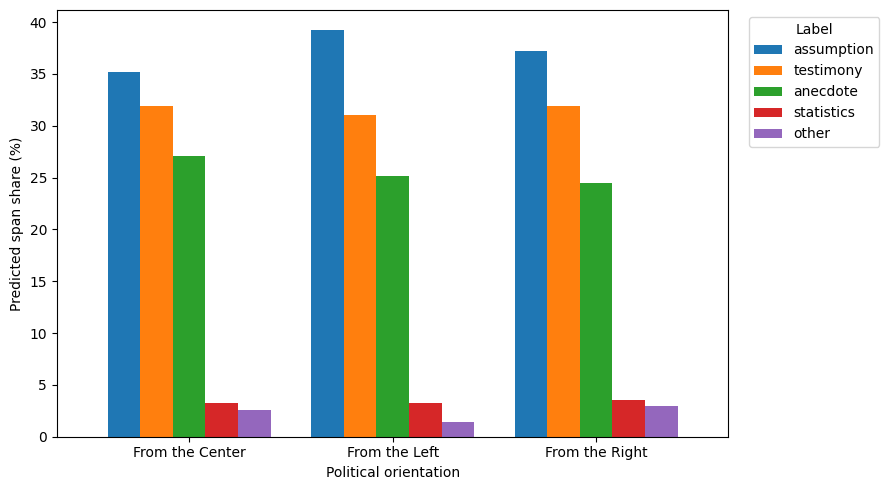

In [39]:
orientation_plot_df = orientation_label_distribution.copy()

ax = orientation_plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.8,
)

ax.set_xlabel("Political orientation")
ax.set_ylabel("Predicted span share (%)")
ax.set_xticklabels(orientation_plot_df.index, rotation=0)
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "orientation_label_shares.pdf",
    bbox_inches="tight",
)

plt.show()

### 11.2 Predicted span density by political orientation

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words for each AllSides political orientation category.

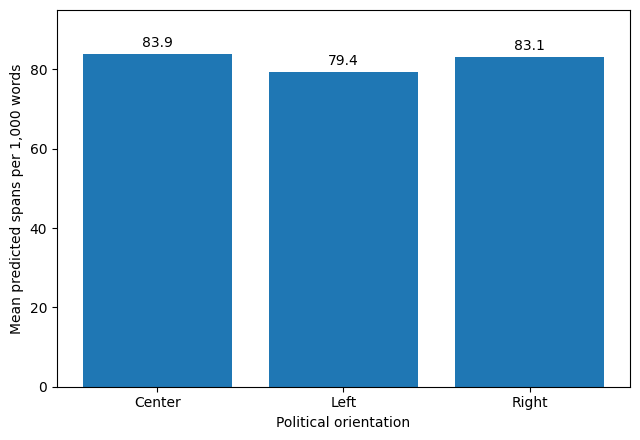

In [40]:
density_plot_df = orientation_density.copy()

density_plot_df["orientation_short"] = (
    density_plot_df["allsides_bias"]
    .str.replace("From the ", "", regex=False)
)

density_plot_df = density_plot_df.set_index("orientation_short").loc[
    ["Center", "Left", "Right"]
].reset_index()

fig, ax = plt.subplots(figsize=(6.5, 4.5))

bars = ax.bar(
    density_plot_df["orientation_short"],
    density_plot_df["mean_spans_per_1000_words"],
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Political orientation")
ax.set_ylabel("Mean predicted spans per 1,000 words")
ax.set_ylim(0, 95)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "orientation_span_density.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "orientation_span_density.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Left-rated articles had more predicted spans per article, but once article length is taken into account, center- and right-rated articles show slightly higher predicted span density.

### 11.3 Predicted label shares by topic

This figure shows the percentage distribution of model-predicted argumentative-unit labels across large topic categories. Only topics with at least 100 articles are included.

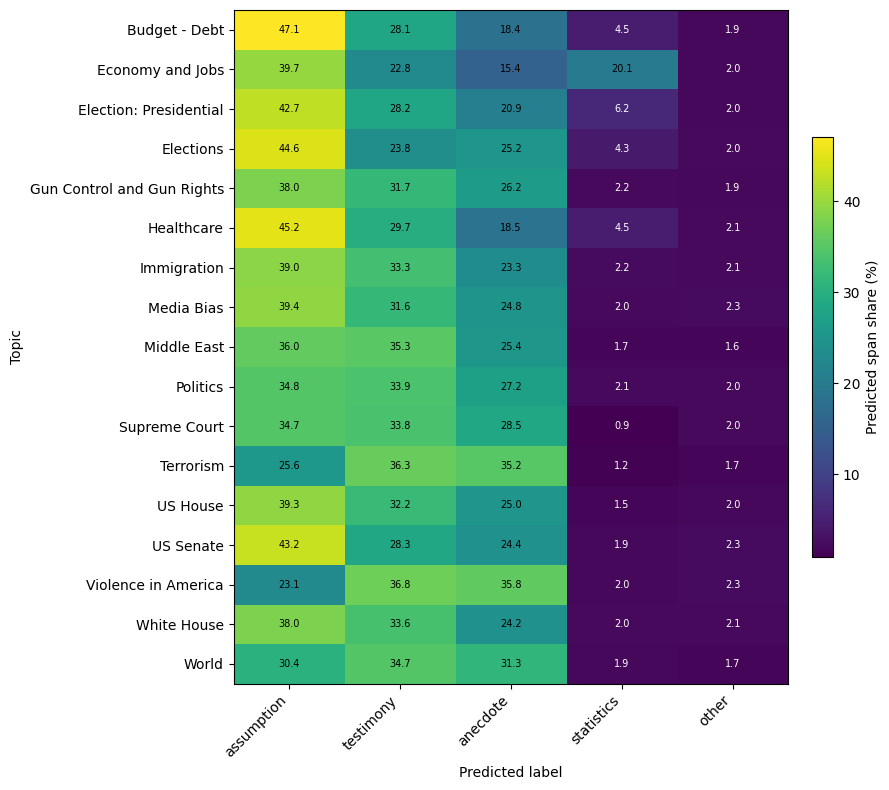

In [41]:
topic_heatmap_df = topic_label_distribution_wide.copy()

fig, ax = plt.subplots(figsize=(9, 8))

values = topic_heatmap_df[LABELS].values

image = ax.imshow(values, aspect="auto")

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45, ha="right")

ax.set_yticks(range(len(topic_heatmap_df.index)))
ax.set_yticklabels(topic_heatmap_df.index)

ax.set_xlabel("Predicted label")
ax.set_ylabel("Topic")

cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Predicted span share (%)")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        text_color = "white" if value < 10 else "black"
        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "topic_label_shares_heatmap.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "topic_label_shares_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 11.4 Predicted span density by topic

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words across topics with at least 100 articles.

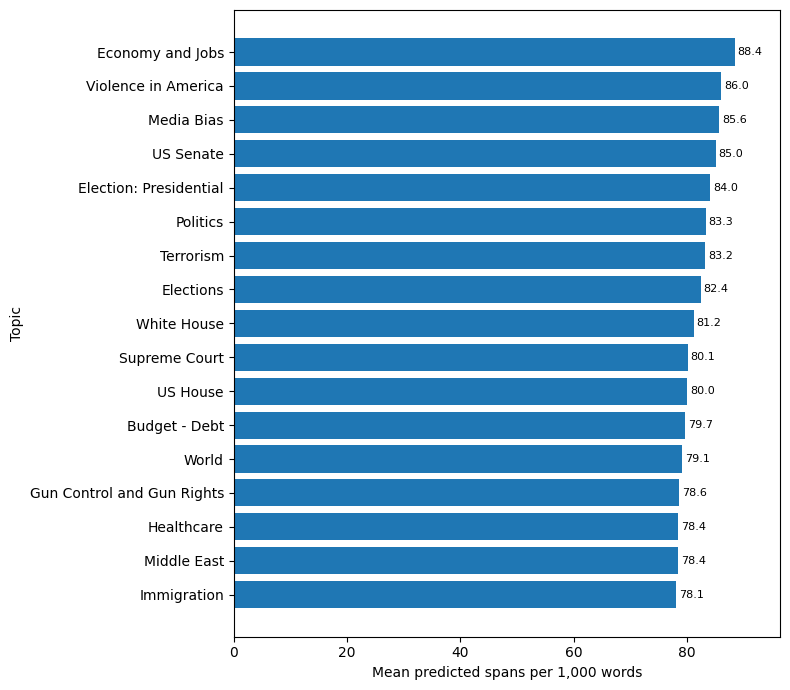

In [42]:
topic_density_plot_df = topic_density.copy()

topic_density_plot_df = topic_density_plot_df.sort_values(
    "mean_spans_per_1000_words",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(
    topic_density_plot_df["topics"],
    topic_density_plot_df["mean_spans_per_1000_words"],
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Mean predicted spans per 1,000 words")
ax.set_ylabel("Topic")
ax.set_xlim(0, topic_density_plot_df["mean_spans_per_1000_words"].max() + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "topic_span_density.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "topic_span_density.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

the main takeaway is that the spread across topics is present but not huge. The highest density appears in Economy and Jobs (88.4), followed by Violence in America (86.0) and Media Bias (85.6), while the lower end includes Immigration (78.1), Middle East (78.4), and Healthcare (78.4). So topic seems to matter, but not in a dramatic all-or-nothing kinda way (ig). --> interesting finding bc it suggests that variation across topics is real, yet still occurs within a fairly comparable overall range.

### 11.5 Mean evidence share by topic

This figure shows the mean evidence share across topics with at least 100 articles.

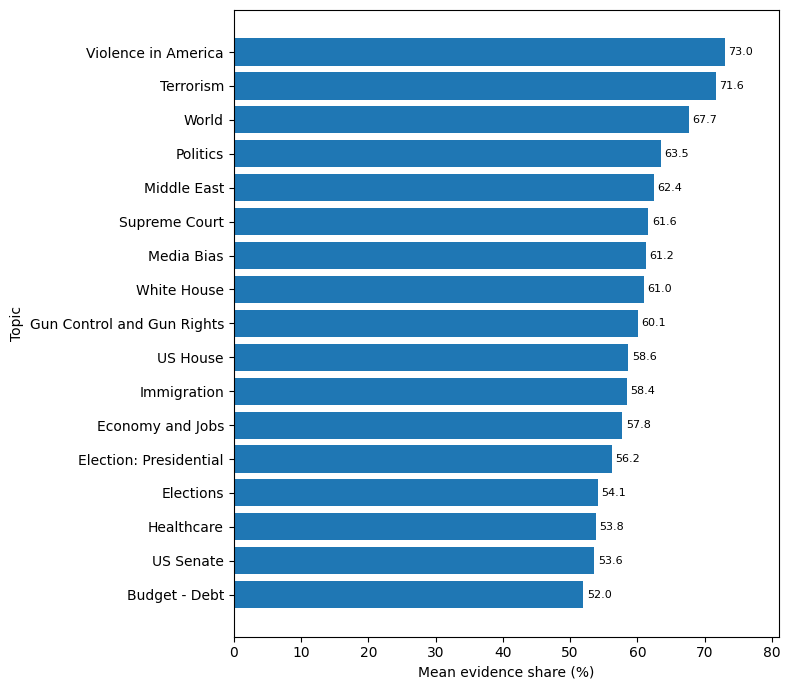

In [43]:
topic_evidence_plot_df = topic_density.copy()

topic_evidence_plot_df = topic_evidence_plot_df.sort_values(
    "mean_evidence_share",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(
    topic_evidence_plot_df["topics"],
    topic_evidence_plot_df["mean_evidence_share"] * 100,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Mean evidence share (%)")
ax.set_ylabel("Topic")
ax.set_xlim(0, topic_evidence_plot_df["mean_evidence_share"].max() * 100 + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "topic_evidence_share.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "topic_evidence_share.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Conflict and event topics such as Violence in America, Terrorism, and World show higher proportions of predicted evidence labels, especially testimony and anecdote. Policy and institutional topics such as Budget - Debt, US Senate, Healthcare, and Elections show lower evidence shares, meaning that a larger proportion of their predicted spans consists of assumptions or other labels.

### 11.6 Predicted span density by source

This figure shows the mean number of model-predicted argumentative-unit spans per 1,000 words for stable sources with at least 50 articles.

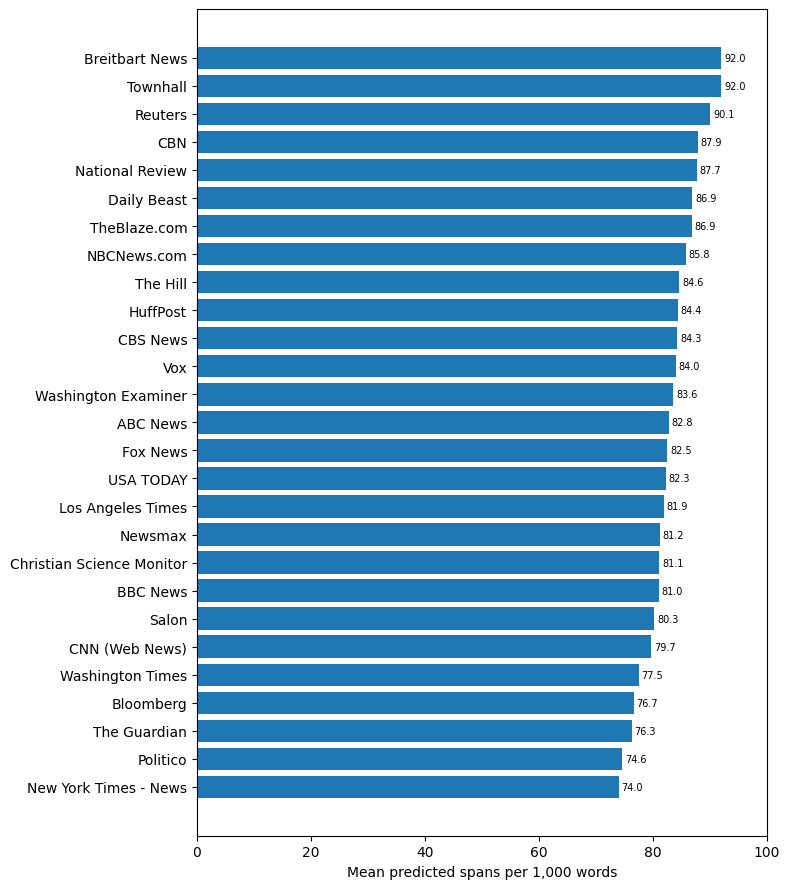

In [44]:
source_density_plot_df = source_density.copy()

source_density_plot_df = source_density_plot_df.sort_values(
    "mean_spans_per_1000_words",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 9))

bars = ax.barh(
    source_density_plot_df["source"],
    source_density_plot_df["mean_spans_per_1000_words"],
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=7,
    )

ax.set_xlabel("Mean predicted spans per 1,000 words")
ax.set_ylabel("")
ax.set_xlim(0, source_density_plot_df["mean_spans_per_1000_words"].max() + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "source_span_density.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "source_span_density.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

This plot might be a bit too big for thesis?

### 11.7 Highest and lowest predicted span density by source

This figure shows the sources with the highest and lowest mean predicted span density among stable sources with at least 50 articles.

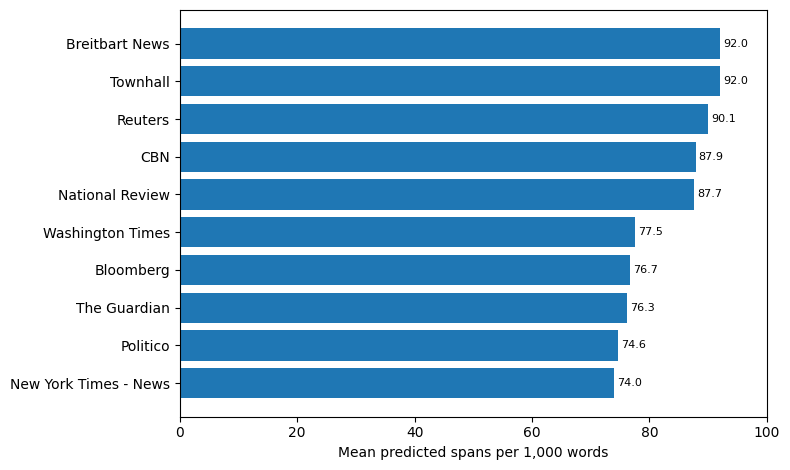

In [45]:
top_n = 5

source_density_extremes = pd.concat([
    source_density.nsmallest(top_n, "mean_spans_per_1000_words"),
    source_density.nlargest(top_n, "mean_spans_per_1000_words"),
])

source_density_extremes = source_density_extremes.sort_values(
    "mean_spans_per_1000_words",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.barh(
    source_density_extremes["source"],
    source_density_extremes["mean_spans_per_1000_words"],
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Mean predicted spans per 1,000 words")
ax.set_ylabel("")
ax.set_xlim(0, source_density_extremes["mean_spans_per_1000_words"].max() + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "source_span_density_extremes.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "source_span_density_extremes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 11.8 Highest and lowest mean evidence share by source

This figure shows the stable sources with the highest and lowest mean evidence share. Evidence share is calculated as the proportion of predicted spans classified as testimony, anecdote, or statistics.

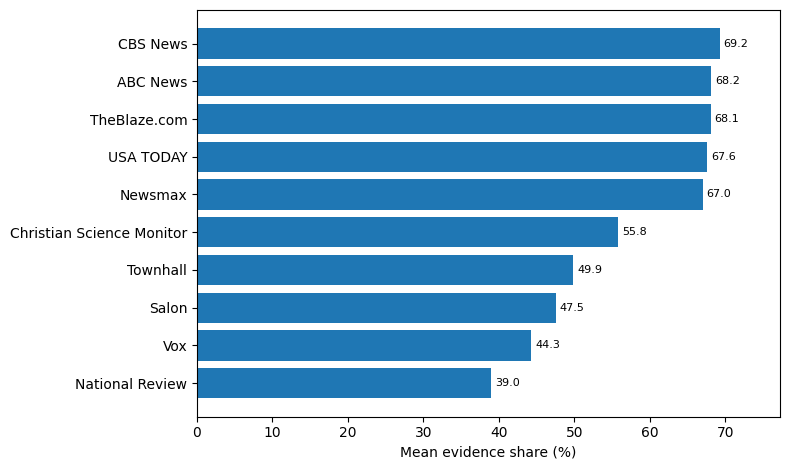

In [46]:
top_n = 5

source_evidence_extremes = pd.concat([
    source_density.nsmallest(top_n, "mean_evidence_share"),
    source_density.nlargest(top_n, "mean_evidence_share"),
])

source_evidence_extremes = source_evidence_extremes.sort_values(
    "mean_evidence_share",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.barh(
    source_evidence_extremes["source"],
    source_evidence_extremes["mean_evidence_share"] * 100,
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Mean evidence share (%)")
ax.set_ylabel("")
ax.set_xlim(0, source_evidence_extremes["mean_evidence_share"].max() * 100 + 8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "source_evidence_share_extremes.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIGURE_DIR / "source_evidence_share_extremes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The comparison of sources with the highest and lowest mean evidence share shows that outlet variation is not limited to overall predicted span density. Some sources show a substantially larger proportion of predicted testimony, anecdote, and statistics, while others show a lower evidence share and a correspondingly larger proportion of predicted assumptions or other spans.